Import all neccessary libraries

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn import metrics
from sklearn.model_selection import GridSearchCV

Load our Microsoft Malware Classification Challenge (BIG 2015) dataset

In [ ]:
import kagglehub as kh

data_path = kh.dataset_download("muhammad4hmed/malwaremicrosoftbig")

df = pd.read_csv(data_path + "/data.csv")
df.shape

Using Colab cache for faster access to the 'malwaremicrosoftbig' dataset.


(10868, 69)

Lets take a deeper look into our dataset

In [ ]:
df.head() #we check our first 5 rows

,asm_commands_add,asm_commands_call,asm_commands_cdq,asm_commands_cld,asm_commands_cli,asm_commands_cmc,asm_commands_cmp,asm_commands_cwd,asm_commands_daa,asm_commands_dd,...,asm_commands_sti,asm_commands_stos,asm_commands_sub,asm_commands_test,asm_commands_wait,asm_commands_xchg,asm_commands_xor,line_count_asm,size_asm,Class
0,436,646.0,0.0,10.0,9.0,0.0,228.0,0.0,56.0,89930,...,1.0,0.0,892.0,53.0,10.0,0.0,162.0,118529,6874624,2
1,469,262.0,0.0,4.0,1.0,4.0,185.0,4.0,20.0,3464,...,3.0,7.0,846.0,8.0,0.0,9.0,19.0,7937,460288,8
2,1587,1828.0,0.0,0.0,31.0,0.0,689.0,0.0,904.0,24833,...,1.0,0.0,4005.0,680.0,44.0,0.0,418.0,90625,5256192,9
3,213,227.0,0.0,0.0,3.0,0.0,127.0,0.0,132.0,71979,...,0.0,0.0,437.0,78.0,0.0,0.0,199.0,83201,4825600,9
4,36,76.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,112,...,2.0,3.0,82.0,16.0,0.0,0.0,18.0,12289,712704,1


In [ ]:
df.columns # we check our column heads

Index(['asm_commands_add', 'asm_commands_call', 'asm_commands_cdq',
       'asm_commands_cld', 'asm_commands_cli', 'asm_commands_cmc',
       'asm_commands_cmp', 'asm_commands_cwd', 'asm_commands_daa',
       'asm_commands_dd', 'asm_commands_dec', 'asm_commands_dw',
       'asm_commands_endp', 'asm_commands_faddp', 'asm_commands_fchs',
       'asm_commands_fdiv', 'asm_commands_fdivr', 'asm_commands_fistp',
       'asm_commands_fld', 'asm_commands_fstp', 'asm_commands_fword',
       'asm_commands_fxch', 'asm_commands_imul', 'asm_commands_in',
       'asm_commands_inc', 'asm_commands_ins', 'asm_commands_jb',
       'asm_commands_je', 'asm_commands_jg', 'asm_commands_jl',
       'asm_commands_jmp', 'asm_commands_jnb', 'asm_commands_jno',
       'asm_commands_jo', 'asm_commands_jz', 'asm_commands_lea',
       'asm_commands_mov', 'asm_commands_mul', 'asm_commands_not',
       'asm_commands_or', 'asm_commands_out', 'asm_commands_outs',
       'asm_commands_pop', 'asm_commands_push', 'asm_com

In [ ]:
print(df.isnull().sum().sum()) # we check for missing data and observed that there is no missing data

0


In [ ]:
df.describe() # we observed that there are alot of outliers in this dataset, datapoints that are far away from the mean

,asm_commands_add,asm_commands_call,asm_commands_cdq,asm_commands_cld,asm_commands_cli,asm_commands_cmc,asm_commands_cmp,asm_commands_cwd,asm_commands_daa,asm_commands_dd,...,asm_commands_sti,asm_commands_stos,asm_commands_sub,asm_commands_test,asm_commands_wait,asm_commands_xchg,asm_commands_xor,line_count_asm,size_asm,Class
count,10868.000000,10868.000000,10868.000000,10868.000000,10868.000000,10868.000000,10868.000000,10868.000000,10868.000000,10868.000000,...,10868.000000,10868.000000,10868.000000,10868.000000,10868.000000,10868.000000,10868.000000,10868.000000,1.086800e+04,10868.000000
mean,724.463839,958.675377,10.774384,200.203165,16.794258,1.900074,480.152742,1.411115,221.034321,16995.688167,...,6.146669,15.102135,2156.040302,330.867777,6.230861,71.709698,493.072874,80667.184026,4.678640e+06,4.017851
std,1568.276158,2891.049563,39.071261,1567.778035,184.439789,35.070993,1384.428550,13.709346,498.249596,32916.498115,...,36.775391,55.051804,6674.654957,1107.955680,17.015893,581.487035,2468.536914,64475.348289,3.739570e+06,2.684621
min,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1942.000000,1.126280e+05,1.000000
25%,140.000000,178.000000,0.000000,0.000000,0.000000,0.000000,8.000000,0.000000,2.000000,217.000000,...,0.000000,0.000000,322.000000,7.000000,0.000000,0.000000,13.000000,15105.000000,8.760320e+05,2.000000
50%,362.000000,261.000000,0.000000,0.000000,1.000000,0.000000,134.500000,0.000000,37.000000,3328.500000,...,1.000000,1.000000,640.000000,50.000000,3.000000,1.000000,81.500000,75364.500000,4.371121e+06,3.000000
75%,766.000000,609.000000,16.000000,2.000000,6.000000,0.000000,401.000000,0.000000,183.000000,18256.000000,...,2.000000,22.000000,1383.000000,188.000000,7.000000,3.000000,273.000000,146433.000000,8.493056e+06,6.000000
max,45684.000000,43479.000000,1384.000000,26600.000000,6830.000000,1540.000000,19617.000000,670.000000,26147.000000,565024.000000,...,1641.000000,1924.000000,130324.000000,25008.000000,515.000000,14725.000000,42457.000000,963585.000000,5.588787e+07,9.000000


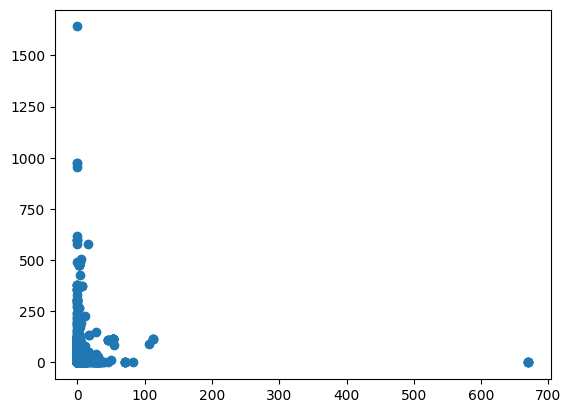

In [ ]:
plt.scatter(df['asm_commands_cwd'], df['asm_commands_sti'])

plt.show()

Let us look at our targets values

In [ ]:
df['Class'].unique()

array([2, 8, 9, 1, 6, 3, 7, 4, 5])

we need to do some feature engineering to label encode our targets so it can start from 0

In [ ]:
target_column = 'Class'

print(f"\nTarget Column: {target_column}")


Target Column: Class


In [ ]:
label_encoder = LabelEncoder()

df[target_column] = label_encoder.fit_transform(
    df[target_column]
)

print("\nNumber of Classes:")
print(len(label_encoder.classes_))


Number of Classes:
9


In [ ]:
df['Class'].unique()

array([1, 7, 8, 0, 5, 2, 6, 3, 4])

Now we need to have our Big X and our target y

In [ ]:
X = df.drop(columns=['Class'], axis=1)
y = df['Class']

X.shape

(10868, 68)

looking at our data description we observed that there are lot of values with large numbers so we need to do **feature scaling**

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()



,asm_commands_add,asm_commands_call,asm_commands_cdq,asm_commands_cld,asm_commands_cli,asm_commands_cmc,asm_commands_cmp,asm_commands_cwd,asm_commands_daa,asm_commands_dd,...,asm_commands_std,asm_commands_sti,asm_commands_stos,asm_commands_sub,asm_commands_test,asm_commands_wait,asm_commands_xchg,asm_commands_xor,line_count_asm,size_asm
0,-0.183945,-0.108158,-0.275775,-0.121326,-0.042261,-0.054180,-0.182143,-0.102936,-0.331243,2.215839,...,-0.065724,-0.139955,-0.274339,-0.189388,-0.250805,0.221517,-0.123327,-0.134123,0.587256,0.587256
1,-0.162902,-0.240988,-0.275775,-0.125153,-0.085638,0.059879,-0.213204,0.188850,-0.403500,-0.411110,...,-0.139101,-0.085568,-0.147180,-0.196280,-0.291422,-0.366196,-0.107849,-0.192055,-1.128083,-1.128083
2,0.550015,0.300709,-0.275775,-0.127705,0.077025,-0.054180,0.150861,-0.102936,1.370793,0.238108,...,-0.074190,-0.139955,-0.274339,0.277025,0.315128,2.219741,-0.123327,-0.030413,0.154451,0.154451
3,-0.326146,-0.253095,-0.275775,-0.127705,-0.074793,-0.054180,-0.255101,-0.102936,-0.178702,1.670465,...,-0.129351,-0.167149,-0.274339,-0.257559,-0.228240,-0.366196,-0.123327,-0.119134,0.039301,0.039301
4,-0.439014,-0.305327,-0.275775,-0.127705,-0.091060,-0.054180,-0.336004,-0.102936,-0.443642,-0.512948,...,-0.109339,-0.112762,-0.219842,-0.310748,-0.284201,-0.366196,-0.123327,-0.192460,-1.060581,-1.060581


we need to split our scaled data into train, valid and test data

In [ ]:


# Step 1: Split into Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled_df,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Step 2: Split Temp into Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (7607, 68)
Validation set: (1630, 68)
Test set: (1631, 68)


now we try our first model to to see the prediction

In [ ]:
model = LogisticRegression(max_iter=1000,random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9503067484662576


now lets do some **feature selection and dimensionality reduction** to reduce our features

In [ ]:
X_scaled_df.shape

(10868, 68)

In [ ]:
pca = PCA(0.90)
x_pca = pca.fit_transform(X_scaled_df)
x_pca.shape

(10868, 27)

In [ ]:
pca.explained_variance_ratio_

array([0.30587457, 0.08521993, 0.0622546 , 0.05288905, 0.04791383,
       0.03441099, 0.02707213, 0.02508311, 0.02286819, 0.01964042,
       0.01844417, 0.01815006, 0.01704376, 0.0159899 , 0.01532755,
       0.01459834, 0.01425819, 0.01322891, 0.01303386, 0.01238038,
       0.01156646, 0.01142137, 0.01051598, 0.0100179 , 0.00928482,
       0.00854755, 0.00784683])

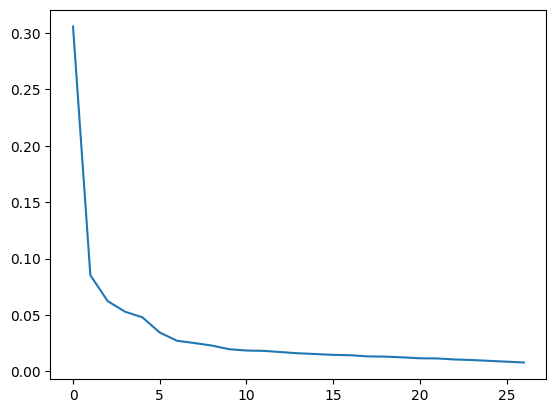

In [ ]:
plt.plot(pca.explained_variance_ratio_)

Now that we have 27 features selected for us, we will do our training again

In [ ]:

# Step 1: Split into Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    x_pca,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Step 2: Split Temp into Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (7607, 27)
Validation set: (1630, 27)
Test set: (1631, 27)


In [ ]:
model = LogisticRegression(max_iter=1000,random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9325153374233128


Ooops, we have a lesser accuracy buh **we will try other models**

In [ ]:
# Create model instances
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(),
    "XGBoost": XGBClassifier(eval_metric="logloss"),
}

we create a for loop to run the training accross all 4 models

In [ ]:
# Train and Evaluate
results = []
for model_name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    Precision = metrics.precision_score(y_val, y_pred, average='weighted')
    Recall = metrics.recall_score(y_val, y_pred, average='weighted')
    F1 = metrics.f1_score(y_val, y_pred, average='weighted')

    end_time = time.time()

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": Precision,
        "Recall": Recall,
        "F1 Score": F1,
        "Training Time": end_time - start_time
    })
    print(f"\n{model_name}")
    print(metrics.classification_report(y_val, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


Logistic Regression
              precision    recall  f1-score   support

           0       0.89      0.88      0.89       231
           1       0.98      0.95      0.97       372
           2       0.99      1.00      0.99       441
           3       0.76      0.99      0.86        71
           4       0.00      0.00      0.00         7
           5       0.89      0.85      0.87       112
           6       0.90      0.95      0.93        60
           7       0.92      0.88      0.90       184
           8       0.88      0.92      0.90       152

    accuracy                           0.93      1630
   macro avg       0.80      0.82      0.81      1630
weighted avg       0.93      0.93      0.93      1630


Random Forest
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       231
           1       0.99      0.98      0.99       372
           2       1.00      1.00      1.00       441
           3       0.89      0.94      0.9

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


Support Vector Machine
              precision    recall  f1-score   support

           0       0.90      0.83      0.86       231
           1       0.98      0.93      0.96       372
           2       0.99      1.00      0.99       441
           3       0.83      0.73      0.78        71
           4       0.00      0.00      0.00         7
           5       0.91      0.84      0.87       112
           6       0.92      0.92      0.92        60
           7       0.65      0.89      0.75       184
           8       0.90      0.84      0.87       152

    accuracy                           0.90      1630
   macro avg       0.79      0.78      0.78      1630
weighted avg       0.91      0.90      0.90      1630


XGBoost
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       231
           1       0.99      0.98      0.98       372
           2       1.00      1.00      1.00       441
           3       0.92      0.96      0.94  

from the model accuracy, **XGBoost** is our best performing model. we also observed a class imbalance for class 4 and it might be because of not enough sample size

In [ ]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time
0,Logistic Regression,0.932515,0.930947,0.932515,0.930876,2.528892
1,Random Forest,0.972393,0.972913,0.972393,0.972296,10.021752
2,Support Vector Machine,0.901840,0.908439,0.901840,0.902516,2.871598
3,XGBoost,0.975460,0.975765,0.975460,0.974706,5.728190


lets plot our Model Accuracy Comparison

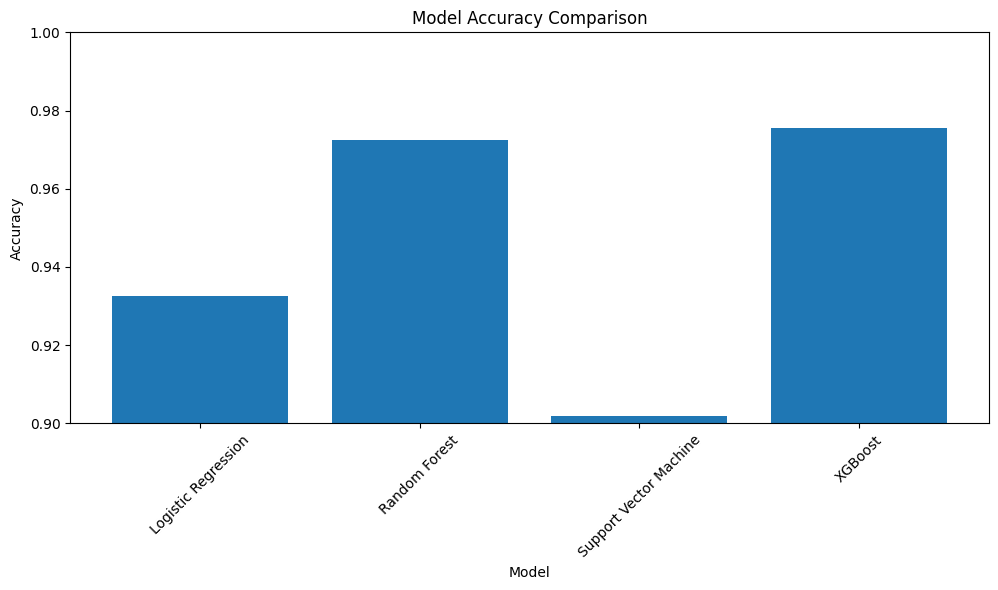

In [ ]:
# Plot accuracy
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylim(0.9, 1.0)
plt.show()

now that we know that XGBOOST is our best model, we are doing to use it to train the train dataset and evaluate on our test dataset

In [ ]:
model = XGBClassifier(random_state=42, eval_metric="logloss")

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
Precision = metrics.precision_score(y_test, y_pred, average='weighted')
Recall = metrics.recall_score(y_test, y_pred, average='weighted')
F1 = metrics.f1_score(y_test, y_pred, average='weighted')


print(f"\n XGBClassifier")
print(f"Accuracy: {accuracy}")
print(f"Precision: {Precision}")
print(f"Recall: {Recall}")
print(f"F1 Score: {F1}")

print(metrics.classification_report(y_test, y_pred))


 XGBClassifier
Accuracy: 0.9840588595953402
Precision: 0.9842952886634273
Recall: 0.9840588595953402
F1 Score: 0.9839365157902701
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       231
           1       0.99      0.99      0.99       372
           2       1.00      1.00      1.00       442
           3       0.97      1.00      0.99        72
           4       1.00      0.67      0.80         6
           5       0.99      0.99      0.99       113
           6       1.00      0.95      0.97        59
           7       0.98      0.96      0.97       184
           8       0.97      0.95      0.96       152

    accuracy                           0.98      1631
   macro avg       0.98      0.94      0.96      1631
weighted avg       0.98      0.98      0.98      1631



we will display our confusion matrics

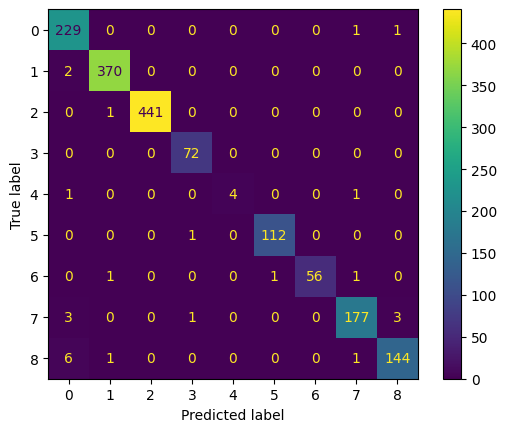

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

we want to do feature important to see our most relevant features

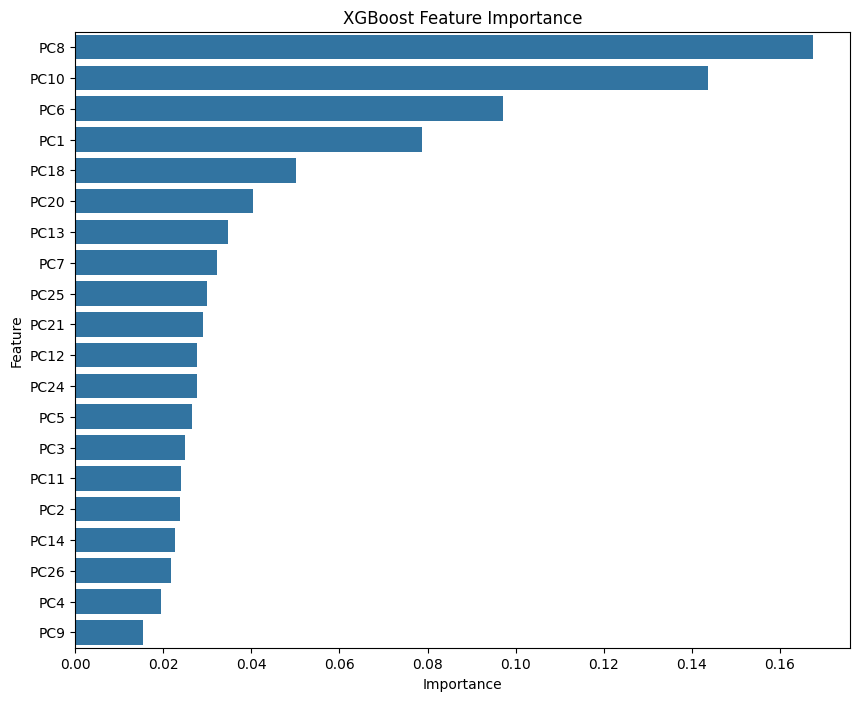

In [ ]:


importance = model.feature_importances_

feature_importance_xgb = pd.DataFrame({
    'Feature': [f'PC{i+1}' for i in range(len(importance))],
    'Importance': importance
})

feature_importance_xgb.sort_values(
    by='Importance',
    ascending=False,
    inplace=True
)



plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance_xgb.head(20),
    x='Importance',
    y='Feature'
)

plt.title("XGBoost Feature Importance")
plt.show()

finally we will do a grid search to hypertune our parameter to get the best parameters

In [ ]:


xgb = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2
)

grid_xgb.fit(X_train, y_train)

print(grid_xgb.best_params_)
print(grid_xgb.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
0.9755982220663985
